# Task 2: Progression / Report of jet classification using graph-based GNN model

## Introduction

In essence, the goal of task 2 is to classify graph representations of quark and gluon jets using a graph based GNN model, and then to evaluate performance 

## Conversion of non-zero pixels into a point cloud dataset

All images mostly contained black space, only about 1.56% of the pixels contained Ecal, Hcal or track pixels, so we asked the simple question: do any of the 3 channels contain non-zero values at this current pixel if yes the pixel was kept if no then it would be thrown away. Each surviving pixel then became a point in the point cloud with 5 values: x position in the 125 x 125 grid, y position in the 125 x 125 grid, it's Ecal value, it's Hcal value and it's tracks value.

## Casting the point cloud data into a graph representation using suitable representations of nodes and edges

After the pixel values were stored in the grid KNN (k Nearest Neighbours) would be used to link up the 8 nearest nodes in this case (the hyperparameter was not adjusted for maximal performance it is just a common starting point) so that a pattern could emerge from these nodes and later be learned by the model. The quark jets tended to be more clustered while, the gluon jets were more spread out and through patterns like this the model would be able to recognise what kind of a graph it was looking at. The reason for KNN specifically over other models was due to jet physics being inherently spatial, particles that are close together in the detector are likely to be physically related and from the same jet. KNN captures this trend naturally by saying connect the 8 closest neighbours in space meaning nodes that are physically nearby in the detector get connected by edges. This allows for the distance between the neighbours to be examined, if the distance between nodes was large then it was likely to be a gluon and if the distance was smaller it was likely a quark.


# Results Of Training

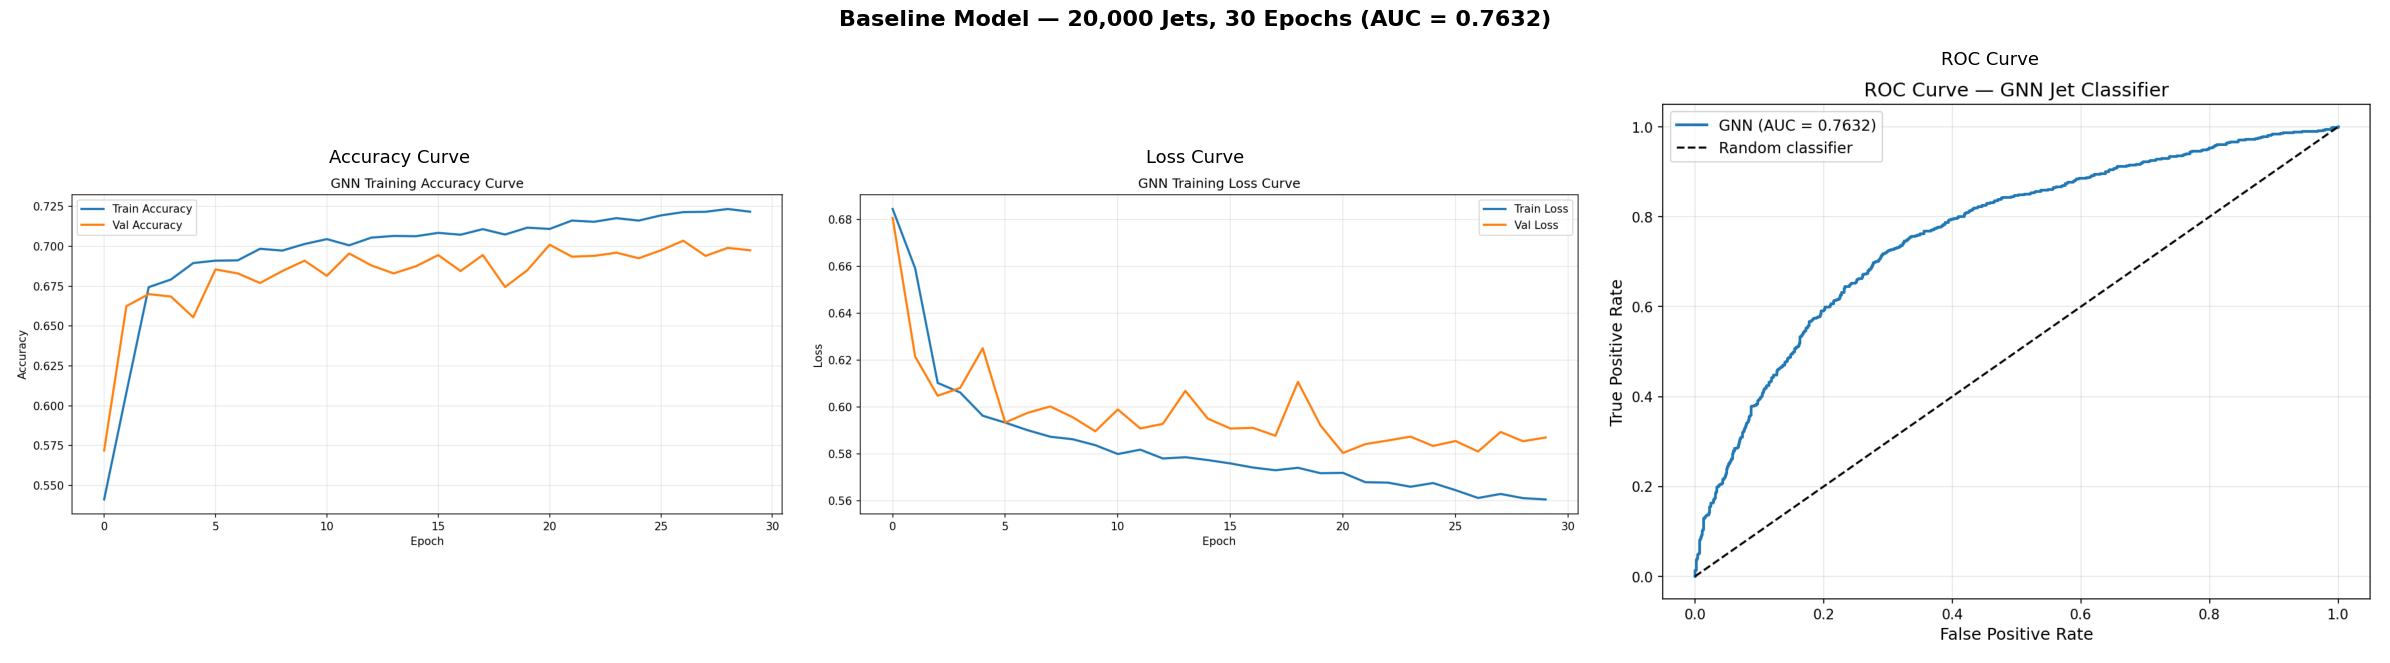

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

base_20k = r"C:\Users\Programmer2\Desktop\task 2\results\results_20,000data_30epochs"

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('Baseline Model — 20,000 Jets, 30 Epochs (AUC = 0.7632)', 
             fontsize=16, fontweight='bold')

for ax, (filename, title) in zip(axes, [
    ('gnn_accuracy_curve.png', 'Accuracy Curve'),
    ('gnn_loss_curve.png', 'Loss Curve'),
    ('roc_curve_gnn.png', 'ROC Curve')
]):
    img = mpimg.imread(f'{base_20k}\\{filename}')
    ax.imshow(img)
    ax.set_title(title, fontsize=13)
    ax.axis('off')

plt.tight_layout()
plt.show()



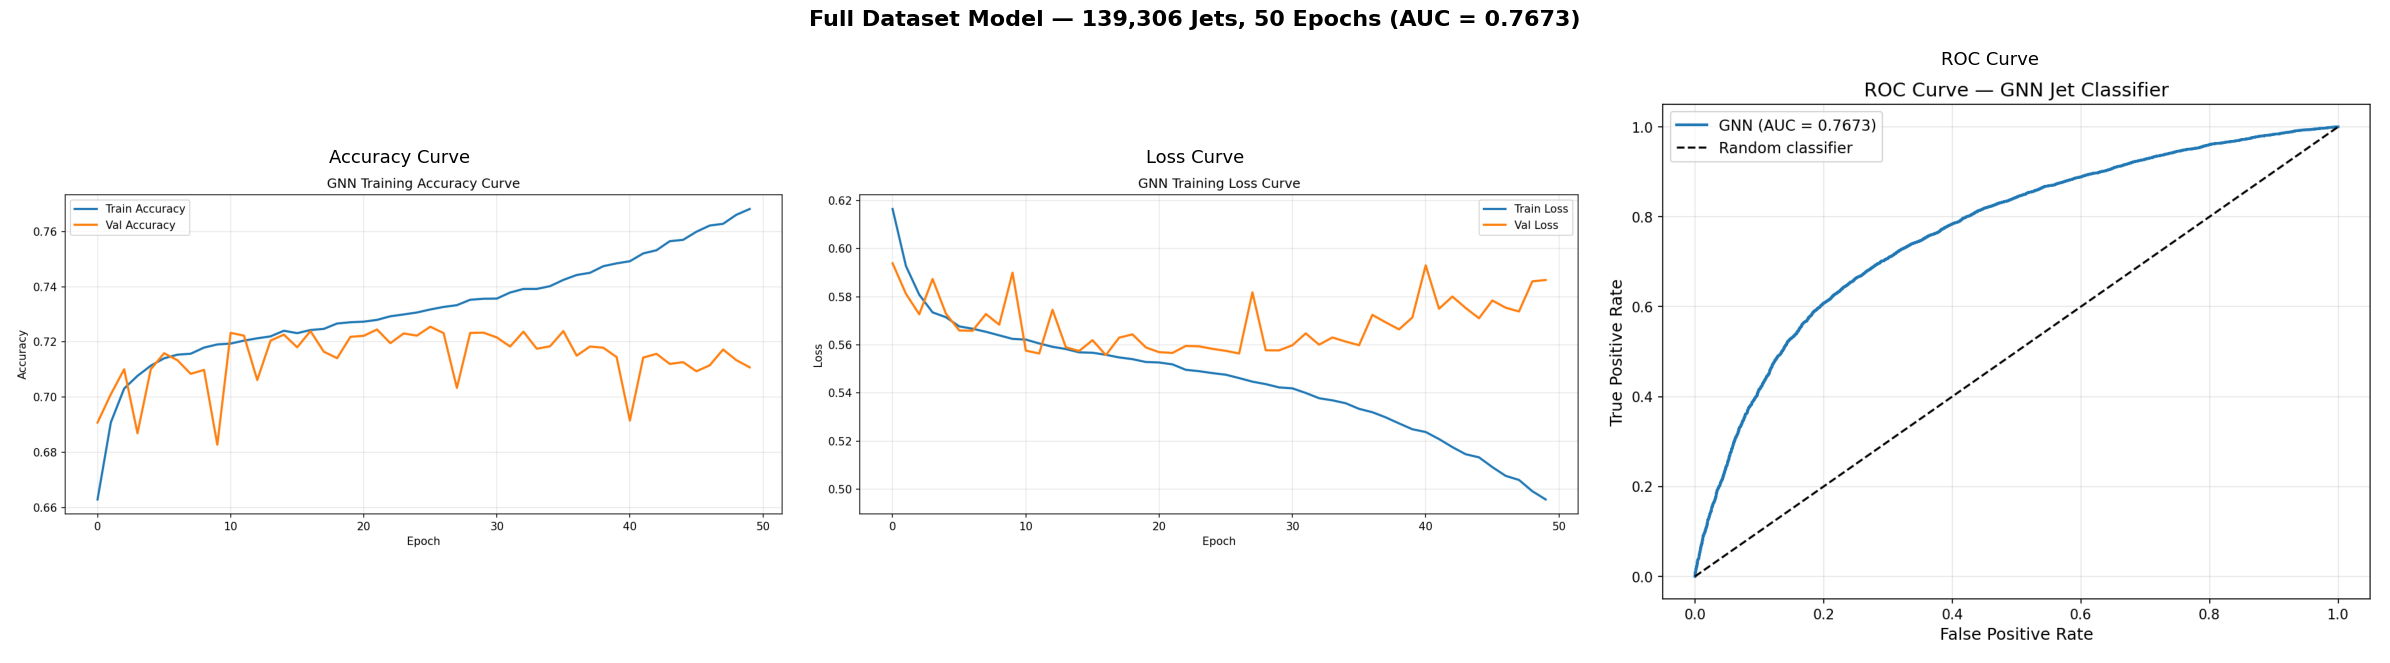

In [4]:
base_full = r"C:\Users\Programmer2\Desktop\task 2\results\results_fulldata_50epochs"

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('Full Dataset Model — 139,306 Jets, 50 Epochs (AUC = 0.7673)', 
             fontsize=16, fontweight='bold')

for ax, (filename, title) in zip(axes, [
    ('gnn_accuracy_curve.png', 'Accuracy Curve'),
    ('gnn_loss_curve.png', 'Loss Curve'),
    ('roc_curve_gnn.png', 'ROC Curve')
]):
    img = mpimg.imread(f'{base_full}\\{filename}')
    ax.imshow(img)
    ax.set_title(title, fontsize=13)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Results of architecture

## ROC curve

20k model: 0.7632

full model: 0.7673

The ROC curve shows how well the model distinguishes quarks from gluons across all possible decision tresholds. The blue curve represents our model and the black dashed diagonal line represents random guessing. One can observe that the models significantly outpreform the random guessing.

## Loss curve

The loss curve tracks the error rate of the model during training, specifically it measures how wrong the model's predicitons are and how confident it was in those wrong predictions. A lower loss means the model is making more correct predicitions with higher confidence. The two lines (train loss and val loss) inform whether the model is learning genuine patterns or just memorising the training data.

Train loss: how accurately and confidently the model makes predicitions on the jets it has already seen (the lower the loss, the less wrong it is so the better)

Val loss: how accurately and confidently it preforms on data it has never seen (the lower the loss, the less wrong it is so the better)


20k model: Both the Train loss and the Val loss decrease steadily together indicating the model is genuienly learning patterns that distinguish quarks from gluons, the graph finishes around 0.56 for the train and 0.59 for the val suggesting there was no sever overfitting and could probably have been further decreased if given the opportunity to further learn 

full model: For the full data set the Train loss and the Val loss do not follow each other the train loss keeps on decreasing while the val loss remains constant/ is slightly increasing suggesting overfitting, so instead of learning patterns to identify between quarks and gluons the model has memorised patterns that only work for the training data.

Hypothesis: Since the full model encounters more data there are more edge cases/ outliers making it harder for the model to create a pattern that will fit everything and at some point this becomes so complex that memorising becomes the easier route rather than adjusting and trying to learn through a different pattern. This then results in overfitting and the model doing well in the training data but not so well in unseen data. 

## Accuracy Curve

The accuracy curve tracks the percentage of classifications that were correct out of all the jets the model was shown but unlike the loss curve it does not care about the confidence.

Train accuracy: the percentage of correct classifications on jets the model has already seen and learned from (higher is better)

Val accuracy: the percentage of correct classifications on jets the model has never seen (higher is better)

20k model: The Train accuracy and Val accuracy go hand in hand together here indicating the model learned a pattern it can use to accurately recognise quarks and gluons 

full model: The Train accuracy and Val accuracy diverge at around 15 epochs suggesting that the point of divergence is where the model started memorising instead of learning a better pattern for recognising quarks and gluons 

Hypothesis: The same hypothesis as for the loss curve: there were such patterns (edge cases / anomalities) that threw off the learned pattern making memorisation (overfitting) easier than learning.


# Improvements of architecture 

## Dropout adjustment

Increasing dropout would force the model to be less reliant on specific neurons and more robust in it's predicitions, in other words it would force the model to find multiple ways to recognise the same pattern allowing for more accurate predicitions.

## Weight decay 

Adding a small penalty to the optimiser for having large weights, these large weights are usually a sign of memorisation. This penalty would force the model to adjust to another way of prediciting getting rid of the memorisation at least partially.

## Data augmentation

Randomly rotating or flipping the jet graphs during training so the model never sees the same graph twice, forcing it to learn a recognition pattern rather than memorising

